In [53]:
import gzip
import pickle
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.insert(0, str(Path('..').resolve()))
from scripts.common import add_galactic, mollweide_scatter

union3_survey_names = [
    'Amanullah10', 'CNIa02', 'CSP', 'CalanTololo',
    'CfA1', 'CfA2', 'CfA3', 'CfA4',
    'DES3_Deep', 'DES3_Shallow', 'ESSENCE',
    'Foundation', 'LOSS', 'MCT', 'NB99',
    'Pan-STARRS', 'Riess07', 'SDSS', 'SNLS',
    'SuzukiRubin', 'Tonry03', 'LSQ+LCO', 'LSQ',
    'knop03', 'Krisciunas'
]

union3_styles = {}
union3_colors = plt.cm.tab20(np.linspace(0, 1, 20)).tolist() + plt.cm.tab20b(np.linspace(0, 1, 5)).tolist()
union3_markers = ['o', 's', '^', 'D', 'v', 'p', 'h', 'H', '<', '>', 'x', '+', 'd', '1', '2',
                  '3', '4', '8', 's', 'p', '*', 'h', 'H', 'D', '^']
for i, name in enumerate(union3_survey_names):
    union3_styles[name] = {'color': union3_colors[i % 25], 'marker': union3_markers[i % 25]}

pickle_file = Path(
    "../data/union3/union3_release/inputs_Amanullah10_CNIa02_CSP_CalanTololo_CfA1_CfA2_CfA3_CfA4_DES3_Deep_DES3_Shallow_"
    "ESSENCE_Foundation_LOSS_MCT_NB99_Pan-STARRS_Riess07_SDSS_SNLS_SuzukiRubin_Tonry03_LSQ+LCO_LSQ_knop03_Krisciunas.pickle"
)

In [54]:
with gzip.open(pickle_file, "rb") as f:
    data = pickle.load(f)

sn_data, metadata, config = data 
print(f"Loaded: {metadata['n_sne']} SNe from {metadata['n_samples']} surveys ({metadata['n_calib']} calibration SNe)")

Loaded: 2087 SNe from 25 surveys (517 calibration SNe)


/tmp/ipykernel_843833/4039795404.py:2: DeprecationWarning: Please import `RectBivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  data = pickle.load(f)


In [55]:
print(f"Element 0 — SN photometry: {len(sn_data)} keys")
for k, v in sn_data.items():
    if hasattr(v, "shape"):
        print(f"  {k}: ndarray {v.shape} {v.dtype}")
    elif isinstance(v, list):
        print(f"  {k}: list[{len(v)}]")
    elif isinstance(v, dict):
        print(f"  {k}: dict keys={list(v.keys())[:5]}")
    else:
        print(f"  {k}: {type(v).__name__} = {v}")

print(f"\nSurvey names ({len(sn_data['sample_names'])}):")
for i, name in enumerate(sn_data['sample_names']):
    survey_label = Path(name).stem.replace("_v1", "")
    count = (sn_data['sample_list'] == i).sum()
    print(f"  [{i:2d}] {survey_label:25s} {count:4d} SNe")

Element 0 — SN photometry: 28 keys
  mB_list: ndarray (2087,) float64
  x1_list: ndarray (2087,) float64
  c_list: ndarray (2087,) float64
  mBx1c_cov_list: ndarray (2087, 3, 3) float64
  z_CMB_list: ndarray (2087,) float64
  z_helio_list: ndarray (2087,) float64
  sample_list: ndarray (2087,) int64
  sample_names: list[25]
  mag_cut_list: ndarray (0,) float64
  mag_cut_disp_list: ndarray (0,) float64
  mass: list[2087]
  mass_err: list[2087]
  snpaths: list[2087]
  RA: list[2087]
  Dec: list[2087]
  mobs_cut0: list[2087]
  mobs_cut1: list[2087]
  est_mobs_cuts: list[25]
  est_mobs_sigmas: list[25]
  efflambs: dict keys=[]
  calib_names: list[517]
  d_mBx1c_dcalib_list: ndarray (2087, 3, 517) float64
  photoz_inds: list[2087]
  d_mBx1c_dz_list: ndarray (0, 3) float64
  photo_z0: list[0]
  photo_dz: list[0]
  n_photoz: int = 0
  photo_spikez: list[0]

Survey names (25):
  [ 0] Amanullah10                  5 SNe
  [ 1] CNIa02                     100 SNe
  [ 2] CSP                        

In [67]:
sn_data.keys()

dict_keys(['mB_list', 'x1_list', 'c_list', 'mBx1c_cov_list', 'z_CMB_list', 'z_helio_list', 'sample_list', 'sample_names', 'mag_cut_list', 'mag_cut_disp_list', 'mass', 'mass_err', 'snpaths', 'RA', 'Dec', 'mobs_cut0', 'mobs_cut1', 'est_mobs_cuts', 'est_mobs_sigmas', 'efflambs', 'calib_names', 'd_mBx1c_dcalib_list', 'photoz_inds', 'd_mBx1c_dz_list', 'photo_z0', 'photo_dz', 'n_photoz', 'photo_spikez', 'l', 'b', 'survey_name'])

In [56]:
print(f"Element 1 — Metadata: {len(metadata)} keys")
for k, v in metadata.items():
    if hasattr(v, "shape"):
        print(f"  {k}: ndarray {v.shape} {v.dtype}")
    elif isinstance(v, list):
        print(f"  {k}: list[{len(v)}]")
    elif isinstance(v, dict):
        print(f"  {k}: dict keys={list(v.keys())[:5]}")
    else:
        print(f"  {k}: {type(v).__name__} = {v}")

Element 1 — Metadata: 38 keys
  n_sne: int = 2087
  nzadd: int = 26
  n_samples: int = 25
  redshift_coeffs: ndarray (2087, 6) float64
  n_calib: int = 517
  d_mBx1c_d_calib: ndarray (2087, 3, 517) float64
  n_x1c_star: int = 6
  threeD_unexplained: int = 1
  mass: list[2087]
  mass_err: list[2087]
  p_high_mass: ndarray (2087,) float64
  do_host_mass: int = 1
  fix_Om: int = 0
  MB_by_sample: int = 0
  sample_list: ndarray (2087,) int64
  zhelio: ndarray (2087,) float64
  redshifts: ndarray (2087,) float64
  redshifts_sort_fill: ndarray (4225,) float64
  unsort_inds: list[2113]
  obs_mBx1c: ndarray (2087, 3) float64
  obs_mBx1c_cov: ndarray (2087, 3, 3) float64
  do_blind: int = 0
  do_twoalphabeta: int = 1
  outl_frac_prior_lnmean: ndarray () float64
  outl_frac_prior_lnwidth: float = 0.5
  n_photoz: int = 0
  d_mBx1c_dz_list: ndarray (0, 3) float64
  photo_z0: list[0]
  photo_dz: list[0]
  spike_redshift_prob: list[0]
  photoz_inds: list[2087]
  photo_spikez: list[0]
  est_mobs_cuts

In [57]:
print(f"Element 2 — Config: {len(config)} keys")
for k, v in config.items():
    if isinstance(v, str):
        print(f"  {k}: str ({len(v)} chars)")
    elif isinstance(v, list):
        print(f"  {k}: list[{len(v)}]")
    elif isinstance(v, type(None)):
        print(f"  {k}: None")
    elif hasattr(v, '__class__') and 'spline' in v.__class__.__name__.lower():
        print(f"  {k}: {type(v).__module__}.{type(v).__qualname__}")
    else:
        print(f"  {k}: {type(v).__name__} = {v}")

Element 2 — Config: 35 keys
  do_blind: int = 0
  filenamelist: list[25]
  weird_sn_list: str (65 chars)
  mag_cut: str (60 chars)
  stan_code: str (35 chars)
  sample_file: None
  calibration_uncertainties: str (47 chars)
  max_params_to_save: int = 10000
  min_redshift: list[25]
  max_redshift: list[25]
  max_firstphase: float = 100.0
  min_lastphase: float = -100.0
  max_color_uncertainty: float = 0.2
  max_color: float = 0.3
  max_MWEBV: float = 0.3
  min_color: float = -0.3
  remap_x1: list[2]
  pec_vel_disp: float = 0.001
  lensing_disp: float = 0.055
  MWEBV_zeropoint_EBV: float = 0.005
  outl_frac: float = 0.02
  redshift_coeff_type: list[4]
  electron_coeff: list[2]
  IG_extinction_coeff: float = 1.0
  do_twoalphabeta: int = 1
  threeD_unexplained: int = 1
  iter: int = 2500
  n_jobs: int = 4
  chains: int = 4
  do_host_mass: int = 1
  fix_Om: int = 0
  MB_by_sample: int = 0
  include_pec_cov: int = 1
  separate_mass_x1c: int = 1
  IG_fn: scipy.interpolate._fitpack2.RectBivari

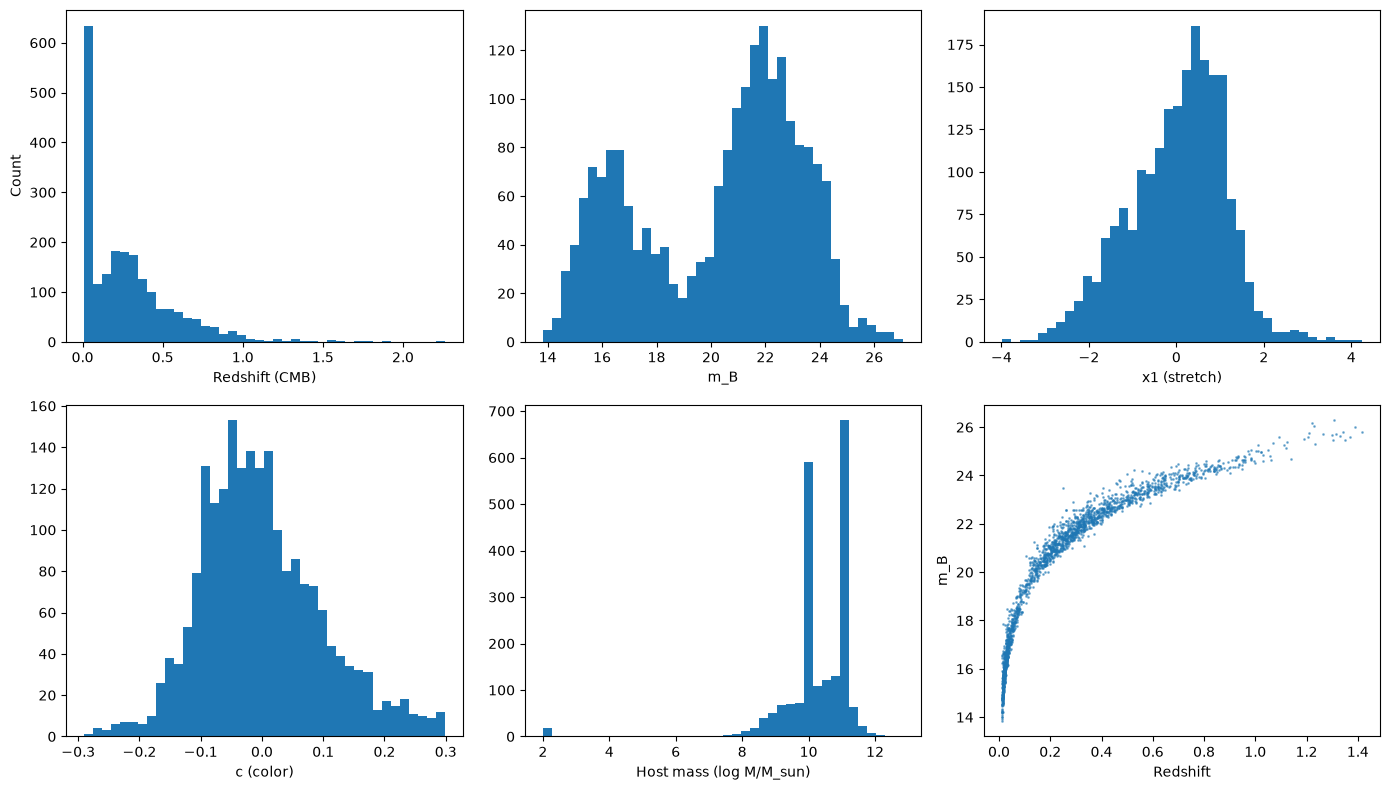

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(sn_data['z_CMB_list'], bins=40)
axes[0, 0].set_xlabel("Redshift (CMB)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(sn_data['mB_list'], bins=40)
axes[0, 1].set_xlabel("m_B")

axes[0, 2].hist(sn_data['x1_list'], bins=40)
axes[0, 2].set_xlabel("x1 (stretch)")

axes[1, 0].hist(sn_data['c_list'], bins=40)
axes[1, 0].set_xlabel("c (color)")

mask = np.array(sn_data['mass']) < 20  # exclude placeholder values
axes[1, 1].hist(np.array(sn_data['mass'])[mask], bins=40)
axes[1, 1].set_xlabel("Host mass (log M/M_sun)")

redshifts = sn_data['z_CMB_list']
mB = sn_data['mB_list']
scatter_mask = (redshifts > 0.01) & (redshifts < 1.5)
axes[1, 2].scatter(redshifts[scatter_mask], mB[scatter_mask], s=1, alpha=0.5)
axes[1, 2].set_xlabel("Redshift")
axes[1, 2].set_ylabel("m_B")

plt.tight_layout()
plt.show()

In [59]:
for i, ra in enumerate(sn_data['RA']):
    if type(ra) != float:
        hours, minutes, seconds = ra.split(":")
        sn_data['RA'][i] = (float(hours) + float(minutes)/60 + float(seconds)/3600) * 15

for i, dec in enumerate(sn_data['Dec']):
    if type(dec) != float:
        sign = 1 if dec[0] != '-' else -1
        degree, minute, second = dec[1:].split(':')
        sn_data['Dec'][i] = sign * (float(degree) + float(minute)/60 + float(second)/3600)

In [60]:
sn_data['l'], sn_data['b'] = add_galactic(np.array(sn_data['RA']), np.array(sn_data['Dec']))
print("Galactic coords added.")

Galactic coords added.


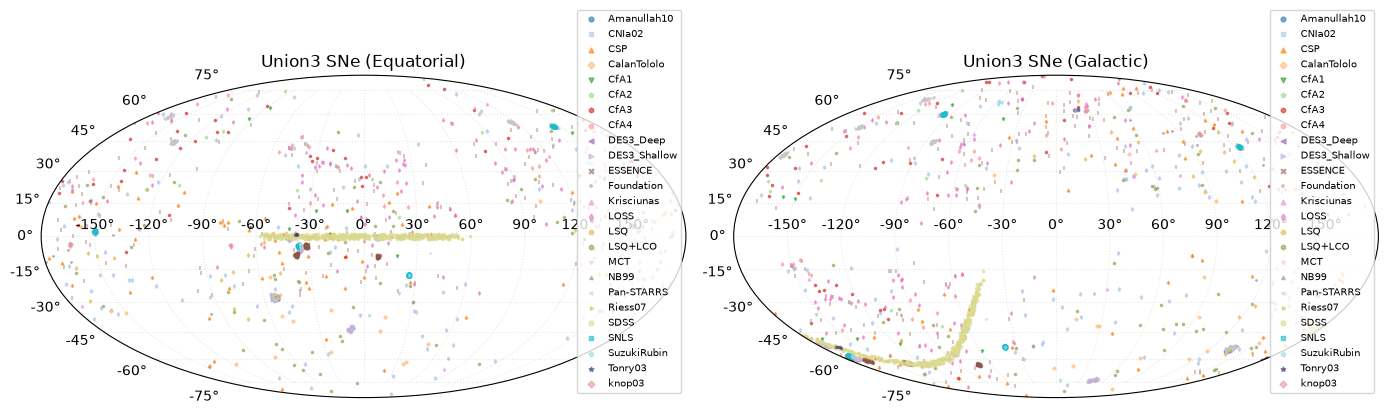

In [61]:
sn_data['survey_name'] = [union3_survey_names[i] for i in sn_data['sample_list']]

fig = plt.figure(figsize=(14, 6))
ax0 = plt.subplot(1, 2, 1, projection='mollweide')
mollweide_scatter(ax0, sn_data['RA'], sn_data['Dec'], sn_data['survey_name'], union3_styles,
                  'Union3 SNe (Equatorial)')

ax1 = plt.subplot(1, 2, 2, projection='mollweide')
mollweide_scatter(ax1, sn_data['l'], sn_data['b'], sn_data['survey_name'], union3_styles,
                  'Union3 SNe (Galactic)')
plt.tight_layout()
plt.show()

In [62]:
print("=== Summary Statistics ===")
print(f"Total SNe: {metadata["n_sne"]}")
print(f"Number of surveys: {metadata["n_samples"]}")
print(f"Redshift range: {sn_data["z_CMB_list"].min():.4f} - {sn_data["z_CMB_list"].max():.4f}")
print(f"Mean apparent magnitude: {sn_data["mB_list"].mean():.3f}")
print(f"Calibration SNe: {metadata["n_calib"]}")

=== Summary Statistics ===
Total SNe: 2087
Number of surveys: 25
Redshift range: 0.0101 - 2.2600
Mean apparent magnitude: 20.296
Calibration SNe: 517
